## 1. Introdução à Computação Numérica e Erros 

**Objetivo da aula:** Compreender a importância e as limitações da resolução numérica computacional. Realizar experimentos numéricos simples usando a linguagem de programação Python. Introduzir a estrutura de repetição `for` e a função `print`, além de alguns operadores aritméticos e a biblioteca `math`. Introduzir a biblioteca `sympy` de computação simbólica e entender a diferença das abordagens analítica e numérica. Compreender as etapas *observação -> modelagem matemática -> resolução* ca matemática computacional aplicada. Observar algumas limitações da máquina ao representar números reais e verificar alguns erros que ocorrem em aritimética de ponto flutuante.    

#### 1.1 O que é matemática computacional?

- A matemática computacional é um ramo da matemática que faz uso da computação para buscar soluções de problemas aplicados em diferentes áreas de conhecimento. 

- Ou seja, resolve modelos matemáticos computacionalmente, por meio de algoritmos e programação de computadores.

- Os computadores são fundamentais para a visualização e a resolução problemas envolvendo grande quantidade de cálculos aritméticos.

- Muitas vezes, até mesmo modelos aparentemente simples podem ser difíceis de resolver por métodos analíticos, ou exatos, nesses casos, os métodos numéricos são a alternativa.


<img src="imagens/matcomp_aplicacoes.png">

**Quais das equações abaixo você consegue resolver "na mão"?**

(a) $2.1x-47.3 = 0$

(b) $x^2+2x-3 = 0$

(c) $senx-x = 0$

(e) $xe^x-2 = 0$

(f) $cos3\theta- sen\theta =0$

(g) $2.1^x+5.7x=0$. 

Algumas equações são relativamente fáceis de resolver analiticamente, outras é preferível utilizar métodos numéricos computacionais.

**Exemplo 1:**   Seja uma esfera de madeira de raio $r$ colocada a flutuar sobre a água conforme figura abaixo. Qual é a altura $d$ da esfera que ficará submersa? 


<img src="imagens/esfera.png" width="200">

Para responder essa pergunta, observemos que, pelo *Princípio de Arquimedes* o peso da esfera deve ser equilibrado com o peso do volume de água deslocada, ou seja, $\mu_e V_e g = \mu_a V_a g$ onde $g$ é a aceleração da gravidade, $\mu_e$ é a densidade relativa da madeira e $\mu_a$ é a densidade relativa da água, $V_e$ e $V_a$ são os volumes. Essa equação nos leva a 

$$ \mu_e \frac{4 \pi r^3}{3} = \mu_a \int_0^d \pi \left[r^2-(x-r)^2 \right]dx $$

$$ \mu_e \frac{4 \pi r^3}{3} = \mu_a \frac{\pi d^2 (3r-d)}{3}$$

substituindo os valores $r=10 cm$,  $\mu_e =0,638 g/cm^3$ e $\mu_a=1 g/cm^3$, com $\pi \approx 3.1415$, podemos chegar à seguinte equação aproximada

$$ 1.047d^3-31.415d^2+2672.369=0$$

Basta resolver essa equação para obter a resposta procurada. Encontrar a solução analítica para esse problema, não é tão simples. No entanto, com uma rotina numérica simples podemos encontrar uma boa aproximação, como será exemplificado na seção seguinte. 

Observe que poderíamos ter multiplicado ambos os lados da equação por $\frac{3}{\pi}$, o que nos daria  

$$d^3-30d^2+2552=0$$

que é uma equação mais precisa, uma vez que não tivemos que usar aproximações, no entanto esse tipo de simplificaçao requer manipular o número $\pi$ como um símbolo. Veremos que frequentemente soluções numéricas geral soluções aproximadas


**Atividade 1:** Vamos investigar se o valor $d = 26.32041$ é uma solução da equação $1.047d^3-31.415d^2+2672.36=0$ usando o código abaixo.

In [5]:
d = 26.32041
print(1.047*d**3-31.415*d**2+2672.369)

0.010648606368249602


Observe que o valor dado pra $d$ é uma aproximação para a solução da equação mas não é um valor exato. Uma aproximação melhor seria  $d=26.3204068433234$. Veja o resultado abaixo.

In [6]:
d = 26.3204068433234
print(1.047*d**3-31.415*d**2+2672.369)

0.00899999998500789


Usando como exemplo o código acima, teste se valor $d= 26.3145706143994$ é uma solução da equação 

$$ \mu_e \frac{4 \pi r^3}{3} = \mu_a \frac{\pi d^2 (3r-d)}{3}.$$

Use os valores $r=10 cm$,  $\mu_e =0,638 g/cm^3$ e $\mu_a=1 g/cm^3$, primeiramene com $\pi=3.1415$ e em seguida com o o valor de $\pi$ dado por

In [7]:
import math
math.pi

3.141592653589793

Verifique também se $d=11.8615$ e $d=-8.1761$ são aproximações para a solução. Quais dos valores pode ser considerado a melhor aproximação para a distância $d$ do Exemplo 1?

#### 1.2 A abordagem numérica

Para entendermos melhor como podemos obter soluções aproximadas por métodos numéricos, vejamos o seguinte exemplo: suponha que você esteja interessado e encontrar a menor raíz da equação $x^2-7x+3=0$. Para essa situação podemos facilmente obter uma solução exata usando fórmula de Bháskara que resulta em $x= \frac{7 \pm \sqrt{37}}{2}$. Por outro lado, podemos também obter uma sequência convergente de aproximações $\{x_1,x_2,...,x_n\}$, a partir de um chute inicial $x_0$, usando a fórmula recursiva  $x_{i+1} = \frac{x_i^2 + 3}{7}$. 

Iniciando com $x_0=1.0$ e fazendo as contas para $x_1, x_2,...$ chegamos, na sexta iteração, em $x_6=0.45862$, que é uma solução aproximada com precisão de cinco casas decimais. Com um pouquinho de conhecimento em Python é fácil gerar esses resultados, basta escrever um pequeno programa, como o que é mostrado a seguir:

In [8]:
x = 1.0
for i in range(6):
    x = x**2/7 +3/7
    print(x)

0.5714285714285714
0.4752186588921283
0.46083325339417613
0.45890961249055157
0.45865686177660403
0.4586237309792518


A fórmula recursiva usada no exemplo acima foi obtida por um método chamado _método do ponto fixo_ que será estudado mais adiante.

Podemos utilizar outras abordagens para obter soluções numéricas de equações, vejamos por exemplo a equação $f(d) = 1.047d^3-31.415d^2+2672.369$ do exemplo descrito anteriormente. Dos dados do problema, podemos inferir que a solução é um número entre 0 e 20, então, calculamos valores da função nesse intervalo e tentar encontrar uma aproximação. Buscamos o valor de $d$ que anula a função $f$, então, observando os resultados na tabera abaixo, podemos concluir que a solução é um número entre 11 e 12 cm pois é o intervalo onde a função muda de sinal.  

In [9]:
for d in range(0,21):
    y = 1.047*d**3-31.415*d**2+2672.369
    print('f(',d,')=', round(y,3))

f( 0 )= 2672.369
f( 1 )= 2642.001
f( 2 )= 2555.085
f( 3 )= 2417.903
f( 4 )= 2236.737
f( 5 )= 2017.869
f( 6 )= 1767.581
f( 7 )= 1492.155
f( 8 )= 1197.873
f( 9 )= 891.017
f( 10 )= 577.869
f( 11 )= 264.711
f( 12 )= -42.175
f( 13 )= -336.507
f( 14 )= -612.003
f( 15 )= -862.381
f( 16 )= -1081.359
f( 17 )= -1262.655
f( 18 )= -1399.987
f( 19 )= -1487.073
f( 20 )= -1517.631


Seguindo o mesmo procedimento mas agora incrementando o valor de $d$ em 0.1 e calculando $f$ para valores de $d$ entre 11 e 12 observamos que a solução está entre $11.8$ e $11.9$. 

In [10]:
for inc in range(0,11):
    d = 11+inc/10
    y = 1.047*d**3-31.415*d**2+2672.369
    print('f(',d,')=', round(y,3))

f( 11.0 )= 264.711
f( 11.1 )= 233.637
f( 11.2 )= 202.631
f( 11.3 )= 171.701
f( 11.4 )= 140.852
f( 11.5 )= 110.091
f( 11.6 )= 79.425
f( 11.7 )= 48.858
f( 11.8 )= 18.399
f( 11.9 )= -11.948
f( 12.0 )= -42.175


Por fim, podemos tomar como solução aproximada o ponto médio entre $11.8$ e $11.9$, ou seja, $d=11.85$. A precisão é de $0.05$.

**Atividade 2:** Use os exemplos acima para encontrar todas as soluções da equação $d^3-30d^2+2552=0$ com uma precisão de $0.005$.

#### 1.3 Computação simbólica
Os recursos computacionais para a matemática não são apenas numéricos, também podem ser de processamentos simbólicos. Um bom exemplo é a biblioteca SymPy. A computação simbólica trata com a computação de objetos matemáticos simbolicamente, ou seja, os objetos matemáticos são representados exatamente, não aproximadamente, e as expressões matemáticas com variáveis não avaliadas são deixadas na forma simbólica.

Como exemplo do uso de Sympy vamos usar computação simbólica para estudar os exemplos dados no começo desse capítulo. O promeiro passo é importar a biblioteca:


In [11]:
import sympy as sp
sp.init_printing(use_unicode=True)

Vamos agora solucionar a equação $x^2-7x+3=0$. Vamos fazer isso definindo $x$ como um símbolo e usando o comando `solve`.

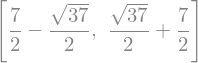

In [12]:
x = sp.symbols('x')
sp.solve(x**2-7*x+3, x)

Observe que a resposta é simbólica e não numérica.  Resposta fornecida é exata.

Também podemos manipular algumas expressões envolvendo integral, por exemplo, vamos calcular a integral $$\mu_a \int_0^d \pi \left[r^2-(x-r)^2) \right]dx$$ de forma simbólica. Para isso definimos os símbolos e usamos o comando `integrate`.


In [13]:
d,x,mua,mue,pi,r = sp.symbols('d, x, mu_a, mu_e,pi,r')

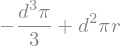

In [14]:
integ = sp.integrate(pi*(r**2-(x-r)**2), (x,0,d))
display(integ)

Obtendo uma forma para a equação do exemplo da esfera. 

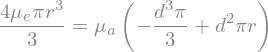

In [15]:
eq = sp.Eq(mue*4*pi*r**3/3,mua*integ)
display(eq)

Por fim, podemos atribuir os valores às constantes e obter uma forma final aproximada.

In [16]:
mue = 0.638
mua = 1.000
r = 10
pi = 3.1415

In [17]:
integ = sp.integrate(pi*(r**2-(x-r)**2), (x,0,d))

In [18]:
sp.Eq(mue*((4*pi*r**3)/3)-mua*integ,0)

Observe que temos aqui aproximações numéricas (inevitáveis), pois ao escrever o número $\pi$ como $3.1415$ estamos obtendo uma aproximação, ou seja, inserindo um pequeno erro na solução final.


**Atividade 3:** Use as funções de Sympy para fazer o que se pede usando computação simbólica: 

(a) Integre a função $f(x)= 2x^2-5sen(2\pi x)$ com `integrate`;

(b) Derive a função $f(x) = 3x^5+cos(3*x)-e^{2x}+1$ usando a função `diff`.

(c) Simplifique a função $\frac{x^2-4}{x-2}$ 
com `simplify`;

(d) Expanda o polinômio $p(x)=(2x-5)^5$ com a função `expand`;

(e) Fatore a expressão $x^2 - 4$ usando `factor`.

#### 1.4 Erros nas aproximações numéricas

Uma solução numérica é uma solução aproximada, não exata. A diferença entre a solução exata e a solução aproximada é chamada de erro e é inerente ao processo, raramente pode ser evitada. Os erros podem ocorrer na tanto fase de modelagem matemática, devido a simplificações e a imprecisão nos dados, quanto na fase de resolução, devido a truncamento ou arredondamento. O truncamento ocorre ao aproximar uma função por uma série infinita usando apenas um número finito de termos e o arredondamento acontece quando não é possível ou necessário reter todos os dígitos da parte fracionária.

Erros de arredondamento também ocorrem devido às limitações que a máquina possui em representar números reais. Nem todos os reais podem ser representados internamente de forma exata. A representação de números reais na maioria dos computadores utiliza o **sistema de ponto flutuante** e **base binária**. Nesse sistema, os números reais são armazenados em um conjunto fixo de bits. Cada bit pode assumir somente dois valores, 0 ou 1 (corte ou passagem de energia, respectivamente). 

Vajamos alguns exemplos:

In [148]:
print(0.2 + 0.1)

0.30000000000000004


Vamos ver outro exemplo. Ao longo desse texto calculamos as soluções  da equação $x^2-7x+3=0$ e obtemos que são $\frac{7}{2}-\frac{\sqrt{37}}{2}$ ou $\frac{7}{2}+\frac{\sqrt{37}}{2}$. Observe o que acontece se substituirmos $x=\frac{7}{2}-\frac{\sqrt{37}}{2}=0.45861873485089033$ na equação

In [149]:
print(0.45861873485089033**2-7*0.45861873485089033+3)

-8.881784197001252e-16


Esperávamos que a resposta fosse $0$ mas ao invés disso obtemos um número muito próximo de zero, mas ainda assim, diferente de zero. Isso ocorre porque ao calcular o valor numérico de $\sqrt{37}$ precisamos fazer uma aproximação. Além disso, o computador possui limitações para representar internamente um número real fazendo com que pequenos erros ocorram. 

Agora vamos calcular $\frac{7}{2}+\frac{\sqrt{37}}{2}$ e substituir na função.

In [150]:
import math
x = 7/2 + math.sqrt(37)/2
print('x =',x)
print('f(x) =',x**2-7*x+3)

x = 6.541381265149109
f(x) = 0.0


Agora a resposta foi 0, ou seja, não aconteceram problemas de representação de numero e de arredondamento nesse caso.

O código abaixo permite visualizar o número mais próximo de 0.1 que o computador consegur representar internamente de forma exata. Observe que o erro aparece depois da 17ª casa decimal. Esse erro é relevante? Pense sobre isso :)

In [151]:
from decimal import Decimal
Decimal(0.1)

Decimal('0.1000000000000000055511151231257827021181583404541015625')

Veja abaixo como é possível visualizar o maior e o menor número real positivo que o computador consegue representar e também a precisão (épsilon da máquina).

In [152]:
import sys  
print ("Máximo representável:", sys.float_info.max)
print ("Mínimo represenável:", sys.float_info.min)
print ("Épsilon da máquina:", sys.float_info.epsilon)

Máximo representável: 1.7976931348623157e+308
Mínimo represenável: 2.2250738585072014e-308
Épsilon da máquina: 2.220446049250313e-16


Observe agora alguns exemplos que mostram como a ordem em que as contas são feitas pode alterar o resultado. Curioso, não é mesmo?

In [153]:
print ("0.2 + 0.4 - 0.5 =", 0.2 + 0.4 - 0.5)
print ("- 0.5 + 0.4 + 0.2 =", - 0.5 + 0.4 + 0.2)
print ("0.2 -0.1 + 0.2 - 0.1 =", 0.2 -0.1 + 0.2 - 0.1)
print ("0.2 - 0.1 + (0.2 - 0.1) =", 0.2 - 0.1 + (0.2 - 0.1))
print ("0.2 + 0.3 + 0.1 =", 0.2 + 0.3 + 0.1 )
print ("0.2 + 0.1 + 0.3 =", 0.2 + 0.1 + 0.3) 

0.2 + 0.4 - 0.5 = 0.10000000000000009
- 0.5 + 0.4 + 0.2 = 0.10000000000000003
0.2 -0.1 + 0.2 - 0.1 = 0.20000000000000004
0.2 - 0.1 + (0.2 - 0.1) = 0.2
0.2 + 0.3 + 0.1 = 0.6
0.2 + 0.1 + 0.3 = 0.6000000000000001


**Exercícios**
1. Por que a saída para a linha de código `0.1 + 0.2 == 0.3` é `False` se o resultado da soma está correto?
2. Faça as operações `0.1*0.2*0.3` e `0.3*0.2*0.1` usando Python e verifique se a ordem dos fatores afeta produto?
3. Pesquise e responda: o que é o “épsilon da máquina”? Faça um programa em Python para obter o épsilon da máquina que você usa.
4. A solução positiva da equação $f(x)=x^2-a$, com $a>0$, pode ser obtida pelo processo iterativo $x_{i+1} = \frac{1}{2} \left(x_i +\frac{a}{x_i} \right)$, $i=0,1,2,...$. Sabendo disso, encontre uma aproximação para $\sqrt{3}$ com 5 casas decimais de precisão.
5. Observe a fórmula de recorrência $x_{i+1}=4x_i -1$ com $i-0,1,2,...$ e $x_0=1/3$ gera uma sequência constante $x_1=x_2=x_3=...=1/3$. Use um programa em Python para gerar essa sequência e veja o que acontece quando o número de elementos aumenta muito. Você saberia explicar o que observa?